# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

| Variable             | Significado                                                                                                                                                                                      |
| -------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `longitude`          | Longitud geográfica del distrito o bloque censal. Indica la posición este-oeste dentro del mapa de California.                                                                                   |
| `latitude`           | Latitud geográfica del distrito o bloque censal. Indica la posición norte-sur dentro del mapa de California.                                                                                     |
| `housing_median_age` | Edad mediana de las viviendas del distrito. Representa cuántos años, en promedio, tienen las viviendas de esa zona.                                                                              |
| `total_rooms`        | Número total de habitaciones en el distrito. Corresponde a la suma de habitaciones de todas las viviendas del área.                                                                              |
| `total_bedrooms`     | Número total de dormitorios en el distrito. Representa la suma de dormitorios de todas las viviendas del área.                                                                                   |
| `population`         | Población total del distrito. Indica cuántas personas viven en esa zona.                                                                                                                         |
| `households`         | Número total de hogares en el distrito. Un hogar representa una unidad habitacional ocupada por una o más personas.                                                                              |
| `median_income`      | Ingreso mediano de los hogares del distrito. Es una medida del nivel socioeconómico de la zona.                                                                                                  |
| `median_house_value` | Valor mediano de las viviendas en el distrito. Esta es la variable objetivo del proyecto, ya que es la que se busca predecir.                                                                    |
| `ocean_proximity`    | Categoría que describe la cercanía del distrito al océano. Permite identificar si la zona está en el interior, cerca de la costa, cerca de la bahía u otras ubicaciones relacionadas con el mar. |


In [1]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/interim/train_set.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (16512, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
1,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
2,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
3,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
4,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN


## Estructura

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428,206333.518653
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936,115314.047529
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500,119200.000000
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500,179200.000000
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000,263925.000000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100,500001.000000


In [5]:
df.sample(5, random_state=42)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14911,-122.25,38.10,52.0,2315.0,556.0,1113.0,486.0,2.5042,147900.0,NEAR BAY
16468,-117.65,34.08,35.0,2621.0,391.0,1074.0,391.0,4.7176,166400.0,INLAND
3550,-122.25,37.77,52.0,2650.0,566.0,1468.0,567.0,3.0161,215700.0,NEAR BAY
1547,-119.74,36.15,21.0,1548.0,308.0,1137.0,306.0,2.4688,61300.0,INLAND
11356,-121.84,37.39,31.0,5524.0,914.0,2848.0,879.0,5.5592,229900.0,<1H OCEAN


In [6]:
df.describe(include="object")

,ocean_proximity
count,16512
unique,5
top,<1H OCEAN
freq,7274


## Completitud

In [7]:
# Completitud de los datos

df.isnull().sum().sort_values(ascending=False)

total_bedrooms        168
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
# Porcentaje de valores faltantes por columna
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

total_bedrooms        1.017442
longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [9]:
faltantes = pd.DataFrame({
    "faltantes": df.isnull().sum(),
    "porcentaje_%": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("porcentaje_%", ascending=False)

faltantes

,faltantes,porcentaje_%
total_bedrooms,168,1.02
longitude,0,0.00
latitude,0,0.00
housing_median_age,0,0.00
total_rooms,0,0.00
population,0,0.00
households,0,0.00
median_income,0,0.00
median_house_value,0,0.00
ocean_proximity,0,0.00


In [10]:
#Vacíos, espacios o etiquetas tipo unknown/null/nan en texto
df["ocean_proximity"].astype(str).str.strip().eq("").sum()

np.int64(0)

In [11]:
df["ocean_proximity"].astype(str).str.lower().isin(["unknown", "null", "nan", "none"]).sum()

np.int64(0)

In [12]:
#Ceros sospechosos en variables donde podrían actuar como faltantes encubiertos
print("households == 0:", (df["households"] == 0).sum())
print("total_rooms == 0:", (df["total_rooms"] == 0).sum())
print("population == 0:", (df["population"] == 0).sum())
print("total_bedrooms == 0:", (df["total_bedrooms"] == 0).sum())

households == 0: 0
total_rooms == 0: 0
population == 0: 0
total_bedrooms == 0: 0


In [43]:
df["tb_missing"] = df["total_bedrooms"].isna().astype(int)

In [44]:
df.groupby("ocean_proximity")["tb_missing"].mean()

ocean_proximity
<1H OCEAN     0.011273
INLAND        0.009244
ISLAND        0.000000
NEAR BAY      0.008667
NEAR OCEAN    0.010053
Name: tb_missing, dtype: float64

In [45]:
df.groupby("tb_missing")[["total_rooms", "population", "households", "median_income"]].mean()

,total_rooms,population,households,median_income
tb_missing,,,,
0,2640.951787,1425.321708,499.931596,3.872020
1,2488.708333,1444.214286,505.690476,3.715555


In [ ]:
# El resultado anterior puede ser MCAR ya que el porcentaje de faltantes por ocean_proximity es muy parecido entre categorías y los promedios de total_rooms, population, households y median_income entre filas con y sin faltantes no cambian de forma fuerte

## Precision

In [13]:
print("Número de filas duplicadas:", df.duplicated().sum())

Número de filas duplicadas: 0


In [14]:
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [15]:
#Revisar valores únicos de la variable categórica
df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [16]:
df["ocean_proximity"].value_counts(dropna=False)

ocean_proximity
<1H OCEAN     7274
INLAND        5301
NEAR OCEAN    2089
NEAR BAY      1846
ISLAND           2
Name: count, dtype: int64

In [17]:
#Revisar valores incorrectos respecto a la realidad
print("median_income <= 0:", (df["median_income"] <= 0).sum())
print("median_house_value <= 0:", (df["median_house_value"] <= 0).sum())
print("housing_median_age < 0:", (df["housing_median_age"] < 0).sum())
print("population < 0:", (df["population"] < 0).sum())
print("households <= 0:", (df["households"] <= 0).sum())
print("total_rooms <= 0:", (df["total_rooms"] <= 0).sum())
print("total_bedrooms <= 0:", (df["total_bedrooms"] <= 0).sum())

median_income <= 0: 0
median_house_value <= 0: 0
housing_median_age < 0: 0
population < 0: 0
households <= 0: 0
total_rooms <= 0: 0
total_bedrooms <= 0: 0


In [18]:
#Coordenadas fuera del rango de California
fuera_california = df[
    (df["latitude"] < 32) | (df["latitude"] > 42) |
    (df["longitude"] < -125) | (df["longitude"] > -114)
]

print("Registros fuera de California:", fuera_california.shape[0])
fuera_california.head()

Registros fuera de California: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


## Consistencia

In [19]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [20]:
#Revisar si la variable categórica está bien como texto
print(df["ocean_proximity"].dtype)

object


In [21]:
#Revisar que las columnas numéricas realmente sean numéricas
df.select_dtypes(include="number").columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [22]:
#Revisar si existen mezclas raras de formato en texto
df["ocean_proximity"].apply(repr).value_counts()

ocean_proximity
'<1H OCEAN'     7274
'INLAND'        5301
'NEAR OCEAN'    2089
'NEAR BAY'      1846
'ISLAND'           2
Name: count, dtype: int64

In [23]:
#Dormitorios no pueden superar al total de habitaciones
(df["total_bedrooms"] > df["total_rooms"]).sum()

np.int64(0)

In [24]:
df[df["total_bedrooms"] > df["total_rooms"]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [25]:
#Hogares no deberían superar a la población
(df["households"] > df["population"]).sum()

np.int64(3)

In [26]:
df[df["households"] > df["population"]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6419,-121.00,39.75,8.0,1116.0,214.0,27.0,39.0,2.5893,83000.0,INLAND
7162,-118.44,34.04,16.0,18.0,6.0,3.0,4.0,0.5360,350000.0,<1H OCEAN
14909,-121.00,37.65,17.0,484.0,202.0,198.0,204.0,0.6825,187500.0,INLAND


In [27]:
#No debería haber hogares si no hay habitaciones
((df["households"] > 0) & (df["total_rooms"] == 0)).sum()

np.int64(0)

In [28]:
#No debería haber población si no hay hogares
((df["population"] > 0) & (df["households"] == 0)).sum()

np.int64(0)

## Sensibilidad

In [29]:
#Resumen con percentiles
df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
longitude,16512.0,-119.573125,2.000624,-124.3500,-123.2000,-122.46000,-121.8000,-118.5100,-118.01,-117.07000,-116.290000,-114.4900
latitude,16512.0,35.637746,2.133294,32.5500,32.6800,32.82000,33.9300,34.2600,37.72,38.95000,40.600000,41.9500
housing_median_age,16512.0,28.577156,12.585738,1.0000,4.0000,8.00000,18.0000,29.0000,37.00,52.00000,52.000000,52.0000
total_rooms,16512.0,2639.402798,2185.287466,2.0000,175.1100,629.00000,1447.0000,2125.0000,3154.00,6235.00000,11226.390000,39320.0000
total_bedrooms,16344.0,538.949094,423.862079,1.0000,38.0000,139.00000,296.0000,434.0000,645.00,1281.00000,2250.710000,6210.0000
population,16512.0,1425.513929,1094.795467,3.0000,89.0000,353.00000,787.0000,1167.0000,1726.00,3309.45000,5801.470000,16305.0000
households,16512.0,499.990189,382.865787,1.0000,32.0000,125.55000,279.0000,408.0000,603.00,1169.45000,1985.890000,5358.0000
median_income,16512.0,3.870428,1.891936,0.4999,1.0714,1.60252,2.5625,3.5385,4.75,7.29847,10.593209,15.0001
median_house_value,16512.0,206333.518653,115314.047529,14999.0000,50000.0000,66100.00000,119200.0000,179200.0000,263925.00,489270.00000,500001.000000,500001.0000


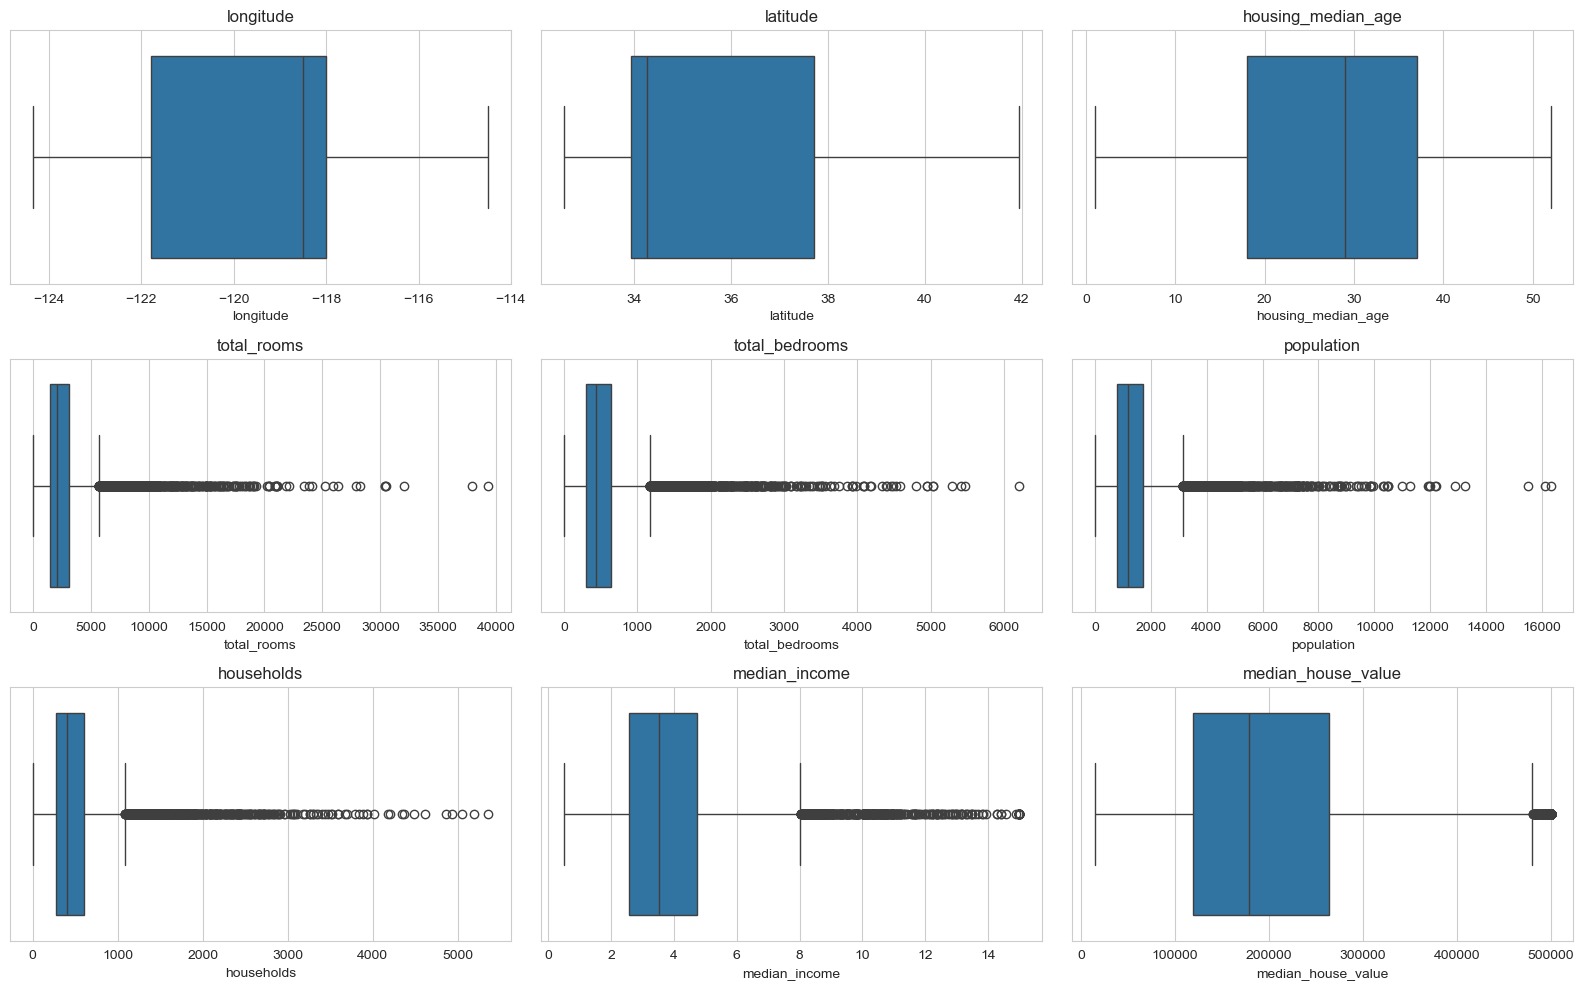

In [30]:
#Boxplots para detectar valores extremos
num_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [31]:
#Revisar mínimos y máximos
for col in df.select_dtypes(include="number").columns:
    print(f"{col}: mínimo = {df[col].min()} | máximo = {df[col].max()}")

longitude: mínimo = -124.35 | máximo = -114.49
latitude: mínimo = 32.55 | máximo = 41.95
housing_median_age: mínimo = 1.0 | máximo = 52.0
total_rooms: mínimo = 2.0 | máximo = 39320.0
total_bedrooms: mínimo = 1.0 | máximo = 6210.0
population: mínimo = 3.0 | máximo = 16305.0
households: mínimo = 1.0 | máximo = 5358.0
median_income: mínimo = 0.4999 | máximo = 15.0001
median_house_value: mínimo = 14999.0 | máximo = 500001.0


## Histogramas

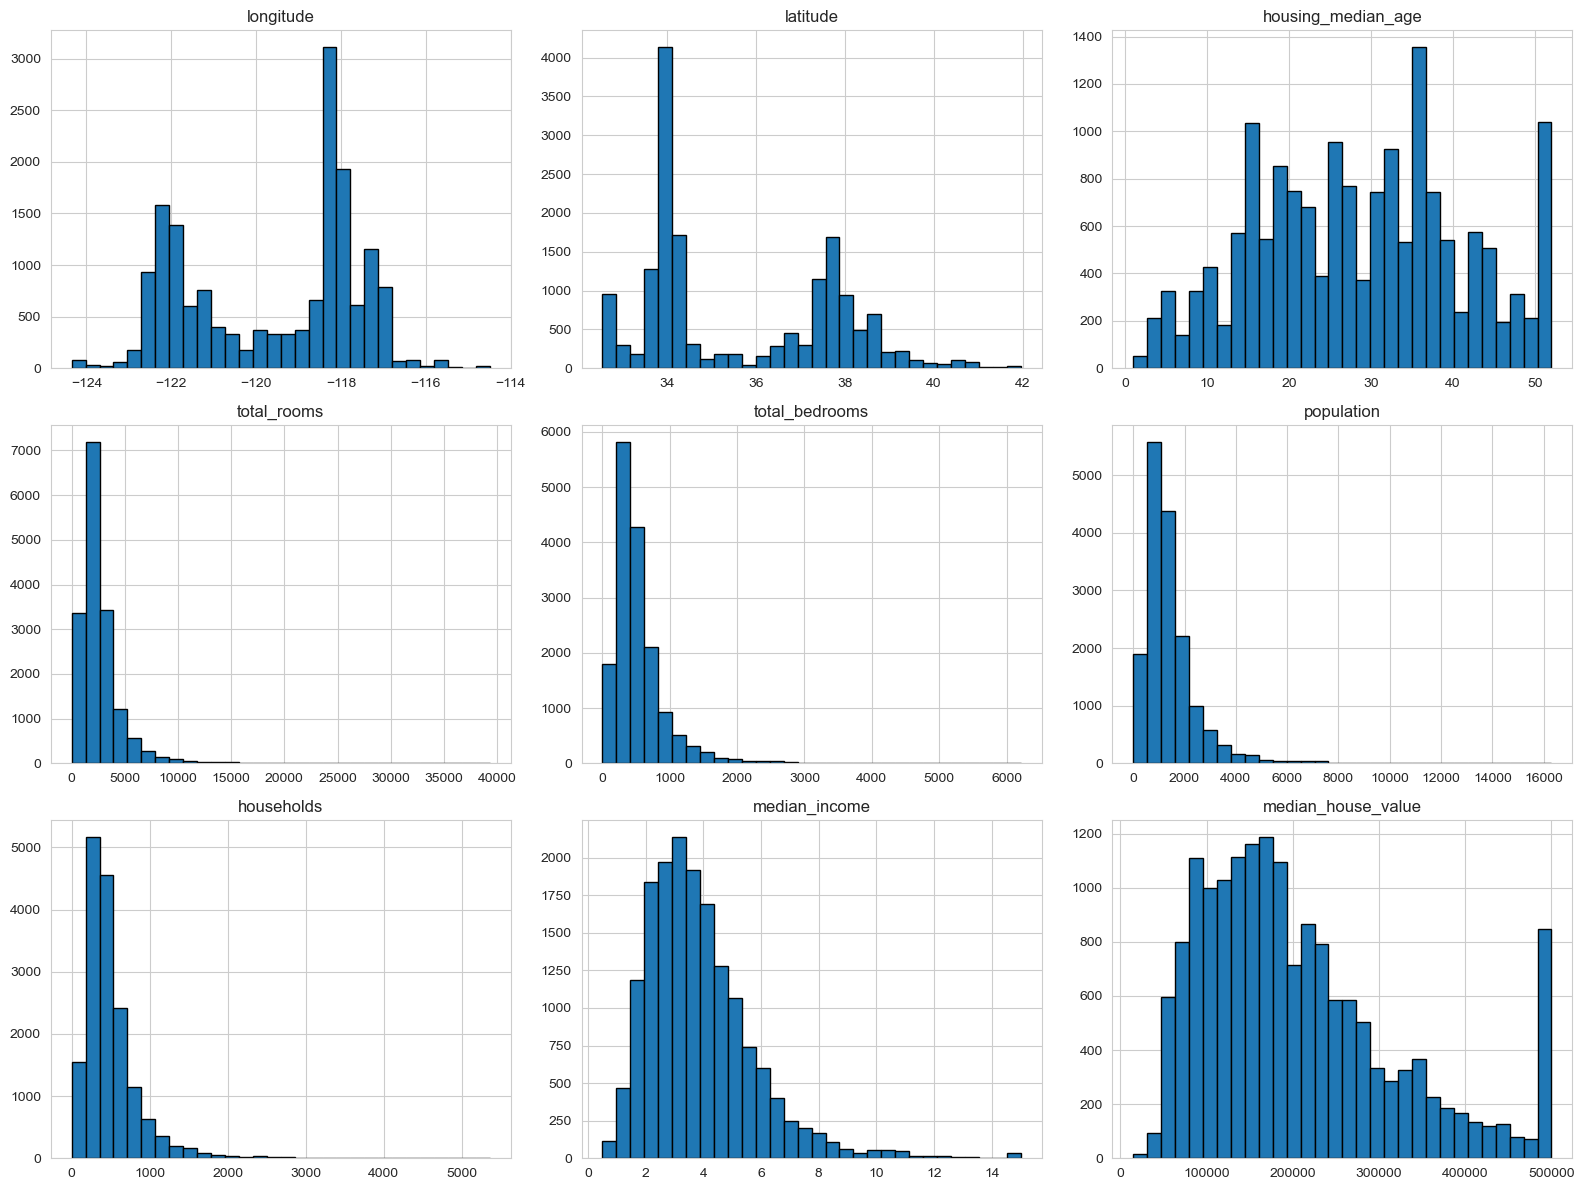

In [32]:
df.hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

## Visualización geoespacial

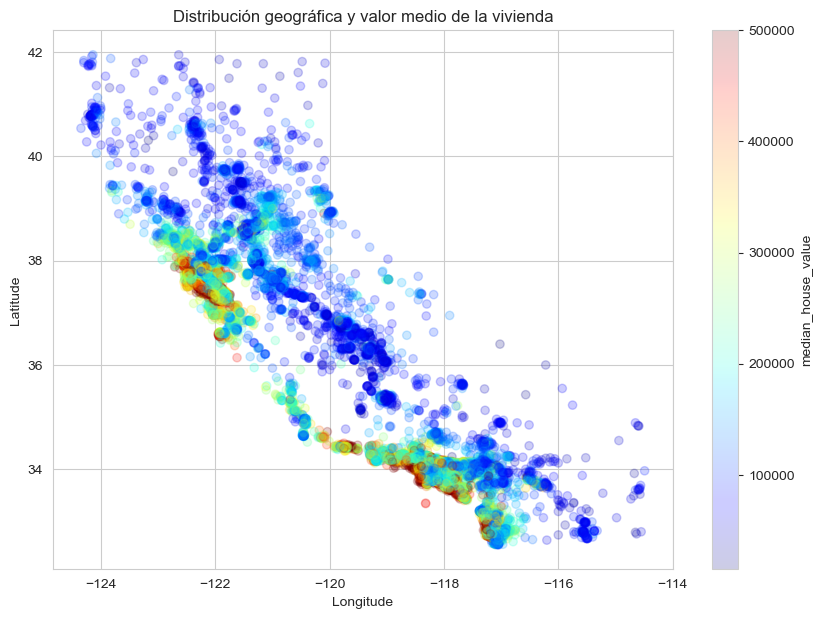

In [33]:
plt.figure(figsize=(10, 7))

graf = plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.2,
    c=df["median_house_value"],
    cmap="jet"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribución geográfica y valor medio de la vivienda")
plt.colorbar(graf, label="median_house_value")
plt.show()

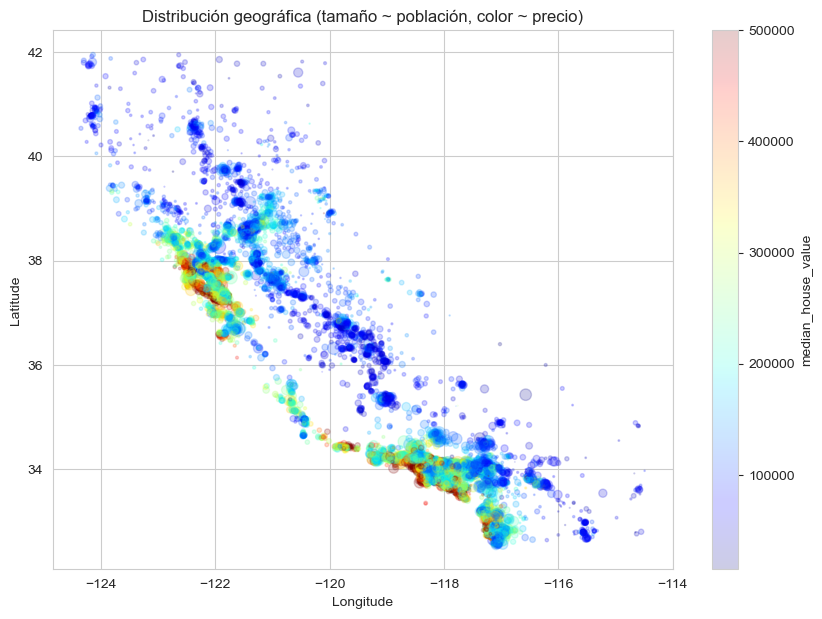

In [34]:
plt.figure(figsize=(10, 7))

graf = plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.2,
    s=df["population"] / 100,
    c=df["median_house_value"],
    cmap="jet"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribución geográfica (tamaño ~ población, color ~ precio)")
plt.colorbar(graf, label="median_house_value")
plt.show()

In [35]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

In [36]:
df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,16512.000000,16344.000000,16512.000000
mean,5.441010,0.212796,2.995974
std,2.574143,0.057417,4.457373
min,0.888889,0.100000,0.692308
25%,4.443636,0.175257,2.433426
50%,5.235573,0.203106,2.822316
75%,6.053843,0.239421,3.286385
max,141.909091,1.000000,502.461538


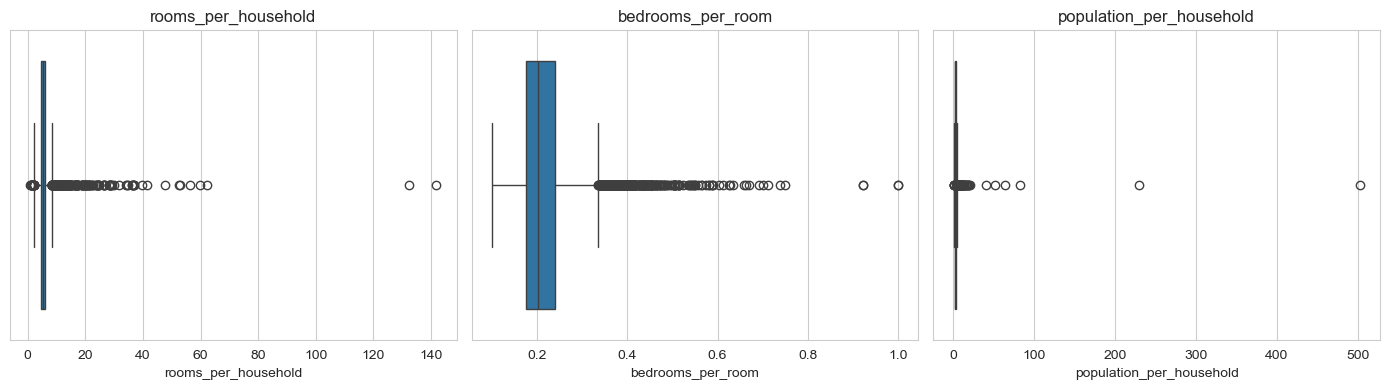

In [37]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x=df["rooms_per_household"])
plt.title("rooms_per_household")

plt.subplot(1, 3, 2)
sns.boxplot(x=df["bedrooms_per_room"])
plt.title("bedrooms_per_room")

plt.subplot(1, 3, 3)
sns.boxplot(x=df["population_per_household"])
plt.title("population_per_household")

plt.tight_layout()
plt.show()

## Correlaciones


In [38]:
corr = df.corr(numeric_only=True)
corr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859,-0.027899,0.087802,0.024587
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584,0.108037,-0.108871,-0.026457
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175,-0.153900,0.139119,0.012771
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455,0.128631,-0.183273,-0.037702
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635,0.001569,0.089931,-0.045017
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153,-0.076603,0.042698,0.085204
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426,-0.082242,0.072046,-0.042452
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380,0.314316,-0.619958,-0.006662
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000,0.143663,-0.256397,-0.038224
rooms_per_household,-0.027899,0.108037,-0.153900,0.128631,0.001569,-0.076603,-0.082242,0.314316,0.143663,1.000000,-0.402221,0.003868


In [39]:
#Correlación con la variable objetivo
corr["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688380
rooms_per_household         0.143663
total_rooms                 0.137455
housing_median_age          0.102175
households                  0.071426
total_bedrooms              0.054635
population                 -0.020153
population_per_household   -0.038224
longitude                  -0.050859
latitude                   -0.139584
bedrooms_per_room          -0.256397
Name: median_house_value, dtype: float64

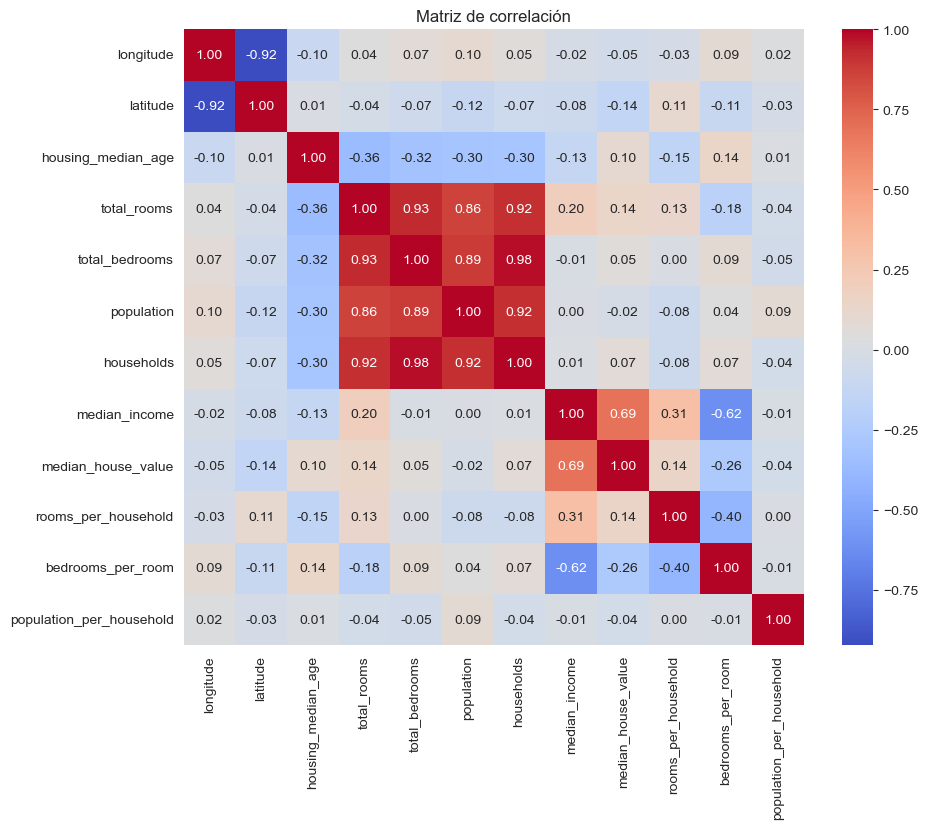

In [40]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

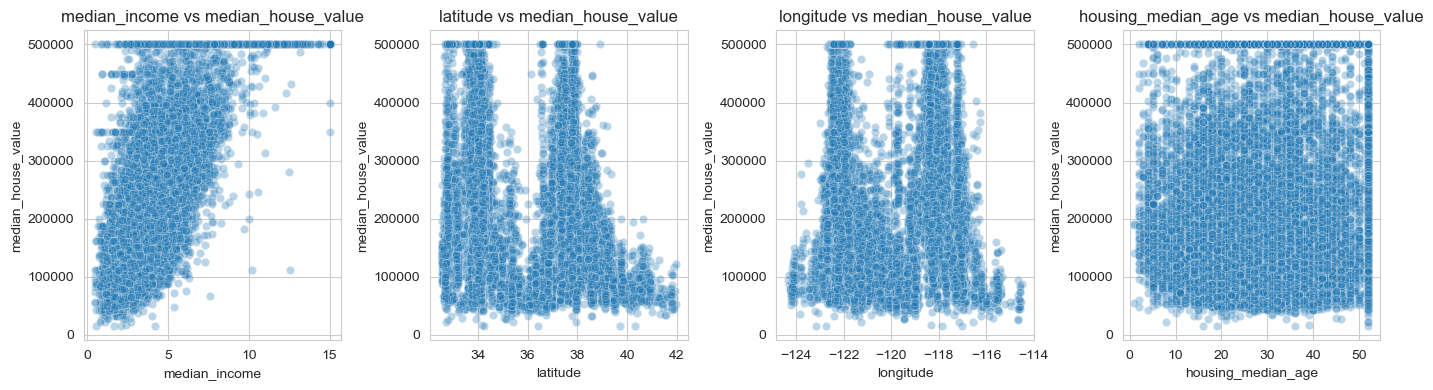

In [41]:
#Gráficos de dispersión con variables relevantes
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
sns.scatterplot(data=df, x="median_income", y="median_house_value", alpha=0.3)
plt.title("median_income vs median_house_value")

plt.subplot(1, 4, 2)
sns.scatterplot(data=df, x="latitude", y="median_house_value", alpha=0.3)
plt.title("latitude vs median_house_value")


plt.subplot(1, 4, 3)
sns.scatterplot(data=df, x="longitude", y="median_house_value", alpha=0.3)
plt.title("longitude vs median_house_value")

plt.subplot(1, 4, 4)
sns.scatterplot(data=df, x="housing_median_age", y="median_house_value", alpha=0.3)
plt.title("housing_median_age vs median_house_value")

plt.tight_layout()
plt.show()

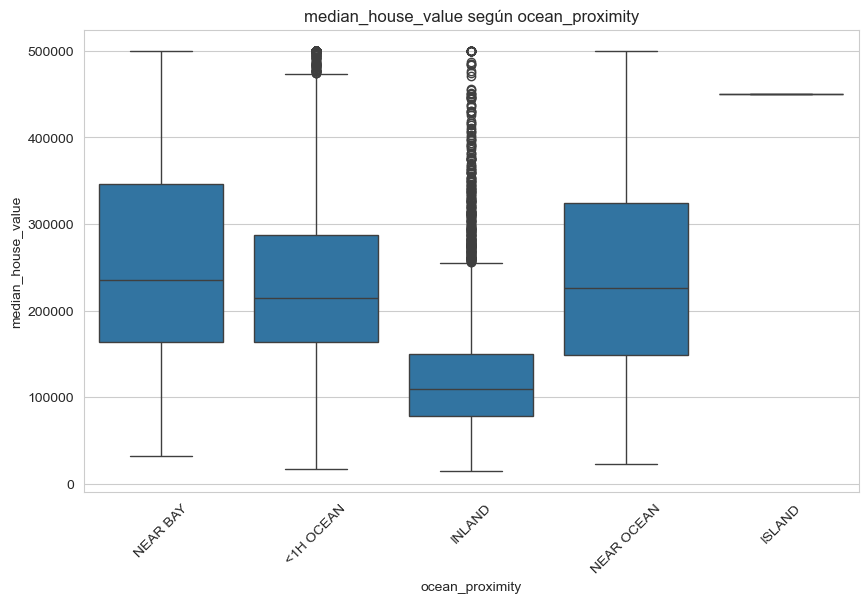

In [42]:
#Relación entre variable categórica y el precio
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value")
plt.xticks(rotation=45)
plt.title("median_house_value según ocean_proximity")
plt.show()

## Conslusiones


1. La calidad general del dataset es adecuada para construir un modelo predictivo. La estructura de los datos es clara, los tipos de variables son coherentes y no se identificaron filas duplicadas.

2. La completitud del dataset es alta. Únicamente la variable total_bedrooms presenta valores faltantes, con un 1,02 % del total, por lo que se trata de un problema puntual y manejable en la etapa de limpieza.

3. Se identificaron pocos problemas de consistencia lógica. En particular, existen 3 registros donde el número de hogares supera a la población, lo cual no resulta coherente desde el punto de vista del negocio y deberá corregirse antes del modelado.

4. No se encontraron errores geográficos relevantes. Las variables latitude y longitude se mantienen dentro de rangos del estado de California, lo que respalda la confiabilidad de la información espacial.

5. Varias variables presentan valores extremos y distribuciones sesgadas. Esto ocurre principalmente en total_rooms, total_bedrooms, population, households, lo que indica que será importante tratar outliers.

6. El ingreso medio del distrito es la variable más relacionada con el precio de la vivienda. La variable median_income presenta la correlación positiva más alta con median_house_value, lo que confirma que el nivel socioeconómico del sector es un factor clave para explicar el valor de las viviendas.

7. La ubicación geográfica tiene un impacto claro sobre los precios. Los gráficos muestran que las zonas cercanas a la costa y al área de la bahía concentran viviendas con valores más altos, mientras que las zonas interiores presentan precios más bajos

8. La variable ocean_proximity segmenta de forma efectiva el mercado inmobiliario. Las categorías cercanas al océano y a la bahía muestran medianas de precio superiores a la categoría INLAND, por lo que esta variable aporta información de negocio valiosa y deberá mantenerse en el modelo.


9. La proporción de dormitorios respecto al total de habitaciones se relaciona negativamente con el precio. La variable bedrooms_per_room muestra una correlación inversa con median_house_value, lo que sugiere que una mayor proporción de dormitorios podría asociarse con viviendas menos amplias o menos valorizadas.


10. Existe alta correlación entre varias variables estructurales del distrito. total_rooms, total_bedrooms, population y households presentan relaciones muy fuertes entre sí, lo que sugiere redundancia de información

11. La variable objetivo presenta evidencia de tope superior. Se observa acumulación de registros en el valor máximo de median_house_value = 500000. Esto sugiere que viviendas con precios reales mayores fueron truncadas en la base, limitando la capacidad del modelo para aprender diferencias dentro del segmento de mayor valor.

12. La categoría ISLAND tiene muy baja representación. Solo contiene 2 registros, por lo que su comportamiento no es suficientemente robusto para extraer conclusiones generales.

14. En conjunto, el dataset presenta una señal predictiva útil. Los patrones encontrados muestran que sí existen relaciones relevantes entre variables socioeconómicas, espaciales y estructurales con el precio medio de la vivienda.